In [1]:
"""
Conversión de espacio de color RGB a HSI (Hue, Saturation, Intensity)
Autor: Natalia Rendón
Curso: Procesamiento de Imágenes
"""

'\nConversión de espacio de color RGB a HSI (Hue, Saturation, Intensity)\nAutor: Natalia Rendón\nCurso: Procesamiento de Imágenes\n'

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import os

In [3]:
def RGB2HSI(rgb_image):
    """
    Convierte una imagen RGB a HSI (Hue, Saturation, Intensity)
    
    Parámetros:
    -----------
    rgb_image : numpy.ndarray
        Imagen en formato RGB con valores de 0 a 255
        
    Retorna:
    --------
    numpy.ndarray
        Imagen en espacio HSI con valores normalizados:
        - H: [0, 1] (0-360 grados normalizado)
        - S: [0, 1]
        - I: [0, 1]
        
    Referencia:
    -----------
    Basado en la fórmula estándar de conversión RGB a HSI
    """
    # Validar entrada
    if rgb_image is None:
        raise ValueError("La imagen no puede ser None")
    
    if len(rgb_image.shape) != 3 or rgb_image.shape[2] != 3:
        raise ValueError("La imagen debe tener 3 canales (RGB)")
    
    # Normalizar valores a rango [0,1]
    rgb_normalized = rgb_image.astype(np.float32) / 255.0
    
    # Extraer canales R, G, B
    R = rgb_normalized[:, :, 0]
    G = rgb_normalized[:, :, 1]
    B = rgb_normalized[:, :, 2]
    
    # Calcular Intensidad (I)
    I = (R + G + B) / 3.0
    
    # Calcular Saturación (S)
    # Evitar división por cero agregando epsilon
    epsilon = 1e-10
    min_rgb = np.minimum(np.minimum(R, G), B)
    S = 1 - (3 * min_rgb) / (R + G + B + epsilon)
    
    # Calcular Hue (H)
    numerator = 0.5 * ((R - G) + (R - B))
    denominator = np.sqrt((R - G)**2 + (R - B)*(G - B))
    
    # Calcular theta (ángulo en radianes)
    # Evitar divisiones por cero
    cos_theta = numerator / (denominator + epsilon)
    # Limitar valores a [-1, 1] para evitar errores numéricos
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    theta = np.arccos(cos_theta)
    
    # Calcular H según el valor de B
    H = theta.copy()
    H[B > G] = 2 * np.pi - H[B > G]
    
    # Normalizar H a [0, 1] (dividiendo entre 2π)
    H = H / (2 * np.pi)
    
    # Combinar canales
    hsi_image = np.dstack((H, S, I))
    
    return hsi_image

def cargar_imagen(ruta_imagen):
    """
    Carga una imagen y la convierte de BGR a RGB
    
    Parámetros:
    -----------
    ruta_imagen : str
        Ruta del archivo de imagen
        
    Retorna:
    --------
    numpy.ndarray
        Imagen en formato RGB
    """
    if not os.path.exists(ruta_imagen):
        raise FileNotFoundError(f"No se encontró la imagen en: {ruta_imagen}")
    
    img = cv2.imread(ruta_imagen)
    
    if img is None:
        raise ValueError(f"No se pudo leer la imagen: {ruta_imagen}")
    
    imagen_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    return imagen_rgb

def visualizar_comparacion(imagen_rgb, imagen_hsi, titulo1="Imagen RGB", titulo2="Imagen HSI"):
    """
    Muestra dos imágenes lado a lado para comparación
    """
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(imagen_rgb)
    plt.title(titulo1)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(imagen_hsi)
    plt.title(titulo2)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

def visualizar_canales_hsi(imagen_hsi):
    """
    Muestra los tres canales H, S, I por separado
    """
    H, S, I = imagen_hsi[:, :, 0], imagen_hsi[:, :, 1], imagen_hsi[:, :, 2]
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    axes[0].imshow(H, cmap='hsv')
    axes[0].set_title('Canal H (Hue)')
    axes[0].axis('off')
    
    axes[1].imshow(S, cmap='gray')
    axes[1].set_title('Canal S (Saturation)')
    axes[1].axis('off')
    
    axes[2].imshow(I, cmap='gray')
    axes[2].set_title('Canal I (Intensity)')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()



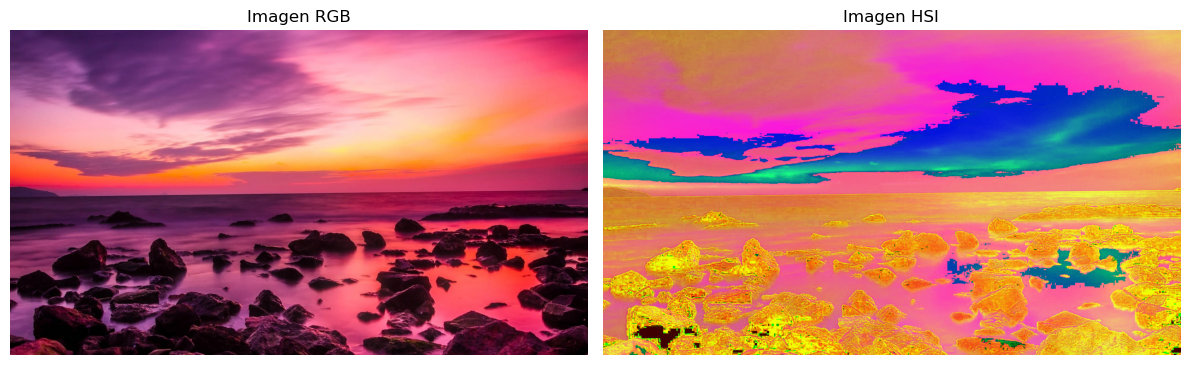

In [ ]:
# ============ EJECUCIÓN PRINCIPAL ============
if __name__ == "__main__":
    try:
        # Ruta de la imagen (cambia según tu imagen)
        ruta_imagen = "sunset.jpg"  # O "sunset.jpg" si está en la raíz
        
     
        imagen_rgb = cargar_imagen(ruta_imagen)
        
   
        imagen_hsi = RGB2HSI(imagen_rgb)
        

        visualizar_comparacion(imagen_rgb, imagen_hsi)
        
        print("Canales HSI por separado: ")
        visualizar_canales_hsi(imagen_hsi)
        
        print("Procesamiento completado exitosamente")
        
    except Exception as e:
        print(f"Error: {e}")
        print("\nSugerencias:")
        print("- Verifica que la imagen exista en la ruta especificada")
        print("- Crea una carpeta 'imagenes/' y coloca tu imagen allí")
        print("- O cambia la variable 'ruta_imagen' a la ubicación correcta")